Purpose: Find the PPDK-RPs (PPDK regulatory proteins) in the three *Yucca* species.<br>
Author: Anna Pardo<br>
Date initiated: May 29, 2026

In [108]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# load orthogroup info
ogs = pd.read_csv("/home/leviathan22/Yucca_genomics/Orthogroups-Yucca_v3_7Oct2025.tsv",sep="\t",header="infer")
ogs.head()

/tmp/ipykernel_1260/3322233443.py:2: DtypeWarning: Columns (1,2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  ogs = pd.read_csv("/home/leviathan22/Yucca_genomics/Orthogroups-Yucca_v3_7Oct2025.tsv",sep="\t",header="infer")


,Orthogroup,Agave_tequiliana,Ananas_comosus,Arabidopsis_thaliana,Asparagus_officinalis_V1.1,Azolla_filiculoides,Brachypodium_distachyon_v3.2,Isoetes_taiwanensis,Kalanchoe_fedtschenkoi,Nymphaea_colorata,Oryza_sativa_v7.0,Peperomia_trollii,Phaelanopsis_equestris,Piper_nigrum,Portulaca_amilis,Yucca_aloifolia,Yucca_filamentosa_v3,Zea_mays
0,OG0000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Ptro.C001G1101.t1, Ptro.C001G1105.t1, Ptro.C00...",NaN,NaN,NaN,NaN,NaN,NaN
1,OG0000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"FUN_000003-T1, FUN_000004-T1, FUN_000086-T1, F...",NaN,NaN,NaN
2,OG0000002,AgateH1.13G059800.1.p,NaN,NaN,NaN,NaN,NaN,NaN,Kaladp0045s0190.1,NaN,NaN,"Ptro.C001G1024.t1, Ptro.C001G1025.t1, Ptro.C00...","PEQU_27888.1, PEQU_30808.1","Pn11.1296, Pn25.138, Pn7.1429","FUN_002586-T1, FUN_006253-T1",NaN,"YufilH1005191m, YufilH1008745m",NaN
3,OG0000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"FUN_000007-T1, FUN_000008-T1, FUN_000022-T1, F...",NaN,NaN,NaN
4,OG0000004,"AgateH1.03G030100.1.p, AgateH1.03G030200.1.p, ...","Aco018614.1, Aco021210.1, Aco021473.1","AT1G48980.1, AT2G17970.1, AT4G36090.3","evm.model.AsparagusV1_01.1455, evm.model.Aspar...",Afil_s0250.g060225,"Bradi1g51390.1.p, Bradi1g51390.2.p, Bradi1g513...","Itaiw.v1.c398g46803, Itaiw.v1.c57g43884","Kaladp0011s0113.1, Kaladp0040s0535.1",Nycol.B01543.1.p,"LOC_Os06g04660.1, LOC_Os06g04660.2","Ptro.C004G11237.t1, Ptro.C005G11726.t1","PEQU_00639.1, PEQU_00652.1, PEQU_00658.1, PEQU...","Pn12.147, Pn3.2614","FUN_008788-T1, FUN_025561-T1, FUN_025562-T1","Yucal.03G026500.1.p, Yucal.03G026600.1.p, Yuca...","YufilH1017244m, YufilH1017245m, YufilH1017246m...","Zm00001eb377750_P001, Zm00001eb377750_P002"


In [7]:
ogs = ogs[["Orthogroup","Arabidopsis_thaliana","Yucca_aloifolia","Yucca_filamentosa_v3"]]
ogs.dropna(subset="Arabidopsis_thaliana",inplace=True)

In [8]:
ogs.head()

,Orthogroup,Arabidopsis_thaliana,Yucca_aloifolia,Yucca_filamentosa_v3
4,OG0000004,"AT1G48980.1, AT2G17970.1, AT4G36090.3","Yucal.03G026500.1.p, Yucal.03G026600.1.p, Yuca...","YufilH1017244m, YufilH1017245m, YufilH1017246m..."
5,OG0000005,"AT1G06180.1, AT1G16490.1, AT1G22640.1, AT1G346...","Yucal.01G220700.1.p, Yucal.01G296700.1.p, Yuca...","YufilH1005218m, YufilH1005219m, YufilH1006851m..."
6,OG0000006,ATMG00750.1,NaN,NaN
7,OG0000007,"AT1G11610.2, AT1G13080.1, AT1G13090.1, AT1G131...","Yucal.01G102400.1.p, Yucal.01G102500.1.p, Yuca...","YufilH1002344m, YufilH1002345m, YufilH1002346m..."
9,OG0000009,"AT3G47090.1, AT3G47110.1, AT3G47570.1, AT3G475...","Yucal.04G189600.1.p, Yucal.04G199600.1.p, Yuca...","YufilH1027659m, YufilH1027664m, YufilH1027665m..."


In [9]:
# list the PPDK-RP gene IDs in Arabidopsis
ppdk_rp_at = ["AT4G21210","AT3G01200"]

In [13]:
# get list of OGs to keep
ogkeep = []
for i in range(len(ogs.index)):
    if ppdk_rp_at[0] in ogs.iloc[i,1]:
        ogkeep.append(ogs.iloc[i,0])
    elif ppdk_rp_at[1] in ogs.iloc[i,1]:
        ogkeep.append(ogs.iloc[i,0])

In [14]:
ogkeep

['OG0007375']

In [15]:
ogs[ogs["Orthogroup"].isin(ogkeep)]

,Orthogroup,Arabidopsis_thaliana,Yucca_aloifolia,Yucca_filamentosa_v3
7375,OG0007375,"AT3G01200.1, AT4G21210.1","Yucal.07G092800.1.p, Yucal.08G163300.1.p","YufilH1048610m, YufilH1067858m"


Investigate the presence of these genes in various analyses: ASE, time-structured, HybridExpress

In [28]:
ppdk_rp = ["Yucal.07G092800.v2.1","Yucal.08G163300.v2.1","YufilH1048610m.g","YufilH1067858m.g"]

In [16]:
# load analysis results (gene lists)
ase = pd.read_csv("./differential_expression/ASE_gttreat_output.txt",sep="\t",header="infer")
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa
1,207.226297,-0.485237,0.071331,-6.802606,1.027436e-11,3.495057e-11,recip_syn3,18_W_aloifolia-V-18_W_filamentosa
2,43.434762,0.344017,0.106880,3.218711,1.287680e-03,2.321305e-03,recip_syn4,18_W_aloifolia-V-18_W_filamentosa
3,52.217998,-1.184873,0.103213,-11.479849,1.665721e-30,1.346501e-29,recip_syn5,18_W_aloifolia-V-18_W_filamentosa
4,390.928299,-0.320654,0.073987,-4.333917,1.464794e-05,3.195546e-05,recip_syn7,18_W_aloifolia-V-18_W_filamentosa


In [19]:
hybexp = pd.read_csv("./differential_expression/expression_partitioning_downstream/hybexp_top30pct_partitiongenes_bygttreat.txt",
                    sep="\t",header="infer")
hybexp.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [20]:
# load TS genes for each species & Yg physiotype
c3ts = pd.read_csv("./masigpro/C3+CAM_TSgenes_9gt.txt",sep="\t",header="infer")
camts = pd.read_csv("./masigpro/CAM_TSgenes_9gt.txt",sep="\t",header="infer")
facts = pd.read_csv("./masigpro/facCAM_TSgenes_9gt.txt",sep="\t",header="infer")

In [21]:
yfts = pd.read_csv("./masigpro/Yf_3reps_masigpro_clusters.txt",sep="\t",header="infer")

In [22]:
yats = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/Ya_hclust_k6_clusters.txt",
                  sep="\t",header="infer")
yats.head()

,cluster,GeneID
0,1,Yucal.01G000500.v2.1
1,2,Yucal.01G000900.v2.1
2,3,Yucal.01G001300.v2.1
3,3,Yucal.01G001400.v2.1
4,4,Yucal.01G002500.v2.1


In [23]:
yfts.head()

,cluster,GeneID
0,1,YufilH1000069m.g
1,1,YufilH1000070m.g
2,2,YufilH1000134m.g
3,3,YufilH1000139m.g
4,4,YufilH1000140m.g


In [24]:
c3ts.head()

,GeneID,subgenome,physiology
0,YufilH1068918m.g,Yf,C3+CAM
1,Yucal.02G260900.v2.1,Ya,C3+CAM
2,Yucal.15G058600.v2.1,Ya,C3+CAM
3,YufilH1007932m.g,Yf,C3+CAM
4,YufilH1093291m.g,Yf,C3+CAM


In [25]:
yats["subgenome"] = "Ya"
yats["physiology"] = "Ya"
yats.drop("cluster",axis=1,inplace=True)

In [26]:
yfts["subgenome"] = "Yf"
yfts["physiology"] = "Yf"
yfts.drop("cluster",axis=1,inplace=True)
yfts.head()

,GeneID,subgenome,physiology
0,YufilH1000069m.g,Yf,Yf
1,YufilH1000070m.g,Yf,Yf
2,YufilH1000134m.g,Yf,Yf
3,YufilH1000139m.g,Yf,Yf
4,YufilH1000140m.g,Yf,Yf


In [27]:
ts_all = pd.concat([yats,yfts,c3ts,camts,facts])

In [31]:
# load synteny information
synlong = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",
                     header="infer")
synlong.head()

,GeneID,syntelogID
0,YufilH1000002m.g,recip_syn1
1,Yucal.01G000100.v2.1,recip_syn1
2,YufilH1000007m.g,recip_syn2
3,Yucal.01G000200.v2.1,recip_syn2
4,YufilH1000011m.g,recip_syn3


In [30]:
ppdk_rp

['Yucal.07G092800.v2.1',
 'Yucal.08G163300.v2.1',
 'YufilH1048610m.g',
 'YufilH1067858m.g']

In [33]:
rpsyn = synlong[synlong["GeneID"].isin(ppdk_rp)]
rpsyn["gene_name"] = rpsyn["syntelogID"].map({"recip_syn16217":"PPDK-RP2","recip_syn23010":"PPDK-RP1"})

/tmp/ipykernel_1260/127098977.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rpsyn["gene_name"] = rpsyn["syntelogID"].map({"recip_syn16217":"PPDK-RP2","recip_syn23010":"PPDK-RP1"})


In [34]:
rp_ts = ts_all[ts_all["GeneID"].isin(ppdk_rp)]
rp_ts = rp_ts.merge(rpsyn)
rp_ts

,GeneID,subgenome,physiology,syntelogID,gene_name
0,Yucal.07G092800.v2.1,Ya,Ya,recip_syn23010,PPDK-RP1
1,Yucal.07G092800.v2.1,Ya,C3+CAM,recip_syn23010,PPDK-RP1
2,Yucal.07G092800.v2.1,Ya,CAM,recip_syn23010,PPDK-RP1
3,Yucal.07G092800.v2.1,Ya,facultative_CAM,recip_syn23010,PPDK-RP1
4,YufilH1067858m.g,Yf,Yf,recip_syn23010,PPDK-RP1


In [35]:
hybexp.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,5.957692,-0.447832,18_D
1,recip_syn10008,1,ADD,0.877055,-1.115803,18_D
2,recip_syn10040,1,ADD,3.715160,-1.074124,18_D
3,recip_syn10057,1,ADD,1.211627,-0.911991,18_D
4,recip_syn10061,1,ADD,3.105884,-1.503516,18_D


In [40]:
rp_he = hybexp[hybexp["Gene"].isin(list(rpsyn["syntelogID"]))]
rp_he = rp_he.merge(rpsyn[["syntelogID","gene_name"]].rename(columns={"syntelogID":"Gene"}))

In [37]:
ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa
1,207.226297,-0.485237,0.071331,-6.802606,1.027436e-11,3.495057e-11,recip_syn3,18_W_aloifolia-V-18_W_filamentosa
2,43.434762,0.344017,0.106880,3.218711,1.287680e-03,2.321305e-03,recip_syn4,18_W_aloifolia-V-18_W_filamentosa
3,52.217998,-1.184873,0.103213,-11.479849,1.665721e-30,1.346501e-29,recip_syn5,18_W_aloifolia-V-18_W_filamentosa
4,390.928299,-0.320654,0.073987,-4.333917,1.464794e-05,3.195546e-05,recip_syn7,18_W_aloifolia-V-18_W_filamentosa


In [41]:
rp_ase = ase[ase["GeneID"].isin(list(rpsyn["syntelogID"]))]
rp_ase = rp_ase.merge(rpsyn[["syntelogID","gene_name"]].rename(columns={"syntelogID":"GeneID"}))

In [42]:
rp_ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast,gene_name
0,1.141503,-2.775808,0.469570,-5.911385,3.392425e-09,9.842421e-09,recip_syn16217,18_W_aloifolia-V-18_W_filamentosa,PPDK-RP2
1,1.141503,-2.775808,0.469570,-5.911385,3.392425e-09,9.842421e-09,recip_syn16217,18_W_aloifolia-V-18_W_filamentosa,PPDK-RP2
2,1.141503,-2.399734,0.456766,-5.253751,1.490320e-07,3.831937e-07,recip_syn16217,2AB_W_aloifolia-V-2AB_W_filamentosa,PPDK-RP2
3,1.141503,-2.399734,0.456766,-5.253751,1.490320e-07,3.831937e-07,recip_syn16217,2AB_W_aloifolia-V-2AB_W_filamentosa,PPDK-RP2
4,1.141503,-2.352157,0.423128,-5.558973,2.713667e-08,6.870539e-08,recip_syn16217,2AB_D_aloifolia-V-2AB_D_filamentosa,PPDK-RP2


In [45]:
rp_ase[(rp_ase["gene_name"]=="PPDK-RP1") & (rp_ase["log2FoldChange"]<0)]["Contrast"].unique()

array(['18_W_aloifolia-V-18_W_filamentosa',
       '2AB_W_aloifolia-V-2AB_W_filamentosa',
       '2AB_D_aloifolia-V-2AB_D_filamentosa',
       '1AB_W_aloifolia-V-1AB_W_filamentosa',
       '18_D_aloifolia-V-18_D_filamentosa',
       '1AB_D_aloifolia-V-1AB_D_filamentosa',
       '19_W_aloifolia-V-19_W_filamentosa',
       '19_D_aloifolia-V-19_D_filamentosa',
       '15_W_aloifolia-V-15_W_filamentosa',
       'Eudy_W_aloifolia-V-Eudy_W_filamentosa',
       'G_W_aloifolia-V-G_W_filamentosa',
       '56_W_aloifolia-V-56_W_filamentosa',
       'G_D_aloifolia-V-G_D_filamentosa',
       '56_D_aloifolia-V-56_D_filamentosa',
       '36_W_aloifolia-V-36_W_filamentosa',
       '36_D_aloifolia-V-36_D_filamentosa',
       '13_W_aloifolia-V-13_W_filamentosa',
       '13_D_aloifolia-V-13_D_filamentosa',
       '45_W_aloifolia-V-45_W_filamentosa',
       '45_D_aloifolia-V-45_D_filamentosa',
       '52_D_aloifolia-V-52_D_filamentosa',
       '43_D_aloifolia-V-43_D_filamentosa',
       '52_W_aloifolia-V

In [46]:
rp_ase[(rp_ase["gene_name"]=="PPDK-RP2") & (rp_ase["log2FoldChange"]<0)]["Contrast"].unique()

array(['18_W_aloifolia-V-18_W_filamentosa',
       '2AB_W_aloifolia-V-2AB_W_filamentosa',
       '2AB_D_aloifolia-V-2AB_D_filamentosa',
       '1AB_W_aloifolia-V-1AB_W_filamentosa',
       '18_D_aloifolia-V-18_D_filamentosa',
       '1AB_D_aloifolia-V-1AB_D_filamentosa',
       '19_W_aloifolia-V-19_W_filamentosa',
       '19_D_aloifolia-V-19_D_filamentosa',
       '15_W_aloifolia-V-15_W_filamentosa',
       'Eudy_W_aloifolia-V-Eudy_W_filamentosa',
       'G_W_aloifolia-V-G_W_filamentosa',
       '56_W_aloifolia-V-56_W_filamentosa',
       'G_D_aloifolia-V-G_D_filamentosa',
       '36_W_aloifolia-V-36_W_filamentosa',
       '36_D_aloifolia-V-36_D_filamentosa',
       '13_W_aloifolia-V-13_W_filamentosa',
       '45_W_aloifolia-V-45_W_filamentosa',
       '45_D_aloifolia-V-45_D_filamentosa',
       '52_D_aloifolia-V-52_D_filamentosa',
       '43_D_aloifolia-V-43_D_filamentosa',
       '52_W_aloifolia-V-52_W_filamentosa',
       '37_W_aloifolia-V-37_W_filamentosa',
       '37_D_aloifolia-V

In [47]:
rp_ase[(rp_ase["gene_name"]=="PPDK-RP2") & (rp_ase["log2FoldChange"]>0)]["Contrast"].unique()

array([], dtype=object)

In [48]:
phys = json.load(open("./physiology/physiological_categories_from_TA.json"))

In [49]:
rp_ase["genotype"] = rp_ase["Contrast"].str.split("_").str[0]
rp_ase["treat"] = rp_ase["Contrast"].str.split("_").str[1]
rp_ase["phys"] = rp_ase["genotype"].map(phys)
rp_ase.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast,gene_name,genotype,treat,phys
0,1.141503,-2.775808,0.469570,-5.911385,3.392425e-09,9.842421e-09,recip_syn16217,18_W_aloifolia-V-18_W_filamentosa,PPDK-RP2,18,W,C3+CAM
1,1.141503,-2.775808,0.469570,-5.911385,3.392425e-09,9.842421e-09,recip_syn16217,18_W_aloifolia-V-18_W_filamentosa,PPDK-RP2,18,W,C3+CAM
2,1.141503,-2.399734,0.456766,-5.253751,1.490320e-07,3.831937e-07,recip_syn16217,2AB_W_aloifolia-V-2AB_W_filamentosa,PPDK-RP2,2AB,W,C3+CAM
3,1.141503,-2.399734,0.456766,-5.253751,1.490320e-07,3.831937e-07,recip_syn16217,2AB_W_aloifolia-V-2AB_W_filamentosa,PPDK-RP2,2AB,W,C3+CAM
4,1.141503,-2.352157,0.423128,-5.558973,2.713667e-08,6.870539e-08,recip_syn16217,2AB_D_aloifolia-V-2AB_D_filamentosa,PPDK-RP2,2AB,D,C3+CAM


In [50]:
rp_ase[rp_ase["gene_name"]=="PPDK-RP1"]["phys"].unique()

array(['C3+CAM', 'facultative CAM', 'CAM'], dtype=object)

In [51]:
rp_ase[rp_ase["gene_name"]=="PPDK-RP2"]["phys"].unique()

array(['C3+CAM', 'facultative CAM', 'CAM'], dtype=object)

In [53]:
rp_he["genotype"] = rp_he["genotype_treat"].str.split("_").str[0]
rp_he["treat"] = rp_he["genotype_treat"].str.split("_").str[1]
rp_he["phys"] = rp_he["genotype"].map(phys)
rp_he.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,gene_name,genotype,treat,phys
0,recip_syn16217,4,ELD_P1,-0.207112,4.810857,18_D,PPDK-RP2,18,D,C3+CAM
1,recip_syn16217,4,ELD_P1,-0.207112,4.810857,18_D,PPDK-RP2,18,D,C3+CAM
2,recip_syn16217,4,ELD_P1,-0.121877,4.894078,2AB_D,PPDK-RP2,2AB,D,C3+CAM
3,recip_syn16217,4,ELD_P1,-0.121877,4.894078,2AB_D,PPDK-RP2,2AB,D,C3+CAM
4,recip_syn16217,4,ELD_P1,0.418497,5.435411,1AB_D,PPDK-RP2,1AB,D,C3+CAM


In [62]:
rp_he[rp_he["Class"]=="ADD"]

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,gene_name,genotype,treat,phys


In [66]:
rpsyn

,GeneID,syntelogID,gene_name
32432,YufilH1048610m.g,recip_syn16217,PPDK-RP2
32433,Yucal.08G163300.v2.1,recip_syn16217,PPDK-RP2
46018,YufilH1067858m.g,recip_syn23010,PPDK-RP1
46019,Yucal.07G092800.v2.1,recip_syn23010,PPDK-RP1


In [100]:
ppdk_rp_dict = {}
for i in range(len(rpsyn.index)):
    if rpsyn.iloc[i,0].startswith("Yufil"):
        ppdk_rp_dict[rpsyn.iloc[i,0]] = "Yf_"+rpsyn.iloc[i,2]
    else:
        ppdk_rp_dict[rpsyn.iloc[i,0]] = "Ya_"+rpsyn.iloc[i,2]

In [86]:
# June 1, 2026
## plot profiles of PPDK-RPs

# previously used functions:
def plottpm_genefamily(tpm, gened=ppdk_rp_dict, add_phys=True):
    genes = [i for i in gened.keys() if i in tpm.columns]

    cols = ["sample_name", "genotype", "treat", "ZT"] + genes
    pwide = tpm[cols].copy()

    plong = pd.melt(
        pwide,
        id_vars=["sample_name", "genotype", "treat", "ZT"],
        value_vars=genes,
        var_name="GeneID",
        value_name="TPM"
    )

    plong["genename"] = plong["GeneID"].map(gened)
    sg = []
    for i in plong["GeneID"]:
        if i.startswith("Yufil"):
            sg.append("Yf")
        else:
            sg.append("Ya")
    plong["subgenome"] = sg

    if add_phys:
        plong["CAM physiology"] = plong["genotype"].map(phys)

    return plong

In [101]:
def build_family_stylemaps(gened=ppdk_rp_dict, yfpal="copper",yapal="winter"):

    genes = list(gened.values())
    yfgenes = [i for i in genes if i.startswith("Yf")]
    yagenes = [i for i in genes if i.startswith("Ya")]

    yf_palette = sns.color_palette(yfpal, n_colors=max(len(yfgenes), 3))
    ya_palette = sns.color_palette(yapal, n_colors=max(len(yagenes), 3))
    color_map = {**dict(zip(yfgenes, yf_palette)), **dict(zip(yagenes,ya_palette))}

    # treatment line styles
    treat_map = {
        "W": "",
        "D": (4, 2)
    }

    return color_map, treat_map

In [70]:
def plot_profile(df, ax, title, color_map, treat_map,
                 log=False, fontsize=18):

    if df.empty:
        ax.set_title(title, fontsize=fontsize)
        return

    plotdf = df.copy()

    ycol = "TPM"

    if log:
        plotdf["logTPM"] = np.log1p(plotdf["TPM"])
        ycol = "logTPM"

    sns.lineplot(
        data=plotdf,
        x="ZT",
        y=ycol,
        hue="genename",        # each gene gets color
        style="treat",        # treatment gets linestyle
        palette=color_map,
        dashes=treat_map,
        estimator="mean",
        errorbar=None,
        lw=2,
        ax=ax
    )

    # dark period shading
    t = np.arange(0, 25)
    ax.fill_between(
        t, 0, 1,
        where=t >= 12,
        color="gray",
        alpha=0.25,
        transform=ax.get_xaxis_transform()
    )

    ax.set_xlim(0, 24)
    ax.set_xticks(sorted(plotdf["ZT"].unique()))
    ax.set_xlabel("")
    ax.set_ylabel("TPM")
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=14)


In [106]:
def plot_genefam_withparents(gened=ppdk_rp_dict, d="./", save=True, log=False):

    # load data
    yaplot = plottpm_genefamily(yatpm, gened, add_phys=False)
    yfplot = plottpm_genefamily(yftpm, gened, add_phys=False)
    gftpm  = plottpm_genefamily(zttpm, gened, add_phys=True)

    # physiology groups
    c3  = gftpm[gftpm["CAM physiology"] == "C3+CAM"]
    fac = gftpm[gftpm["CAM physiology"] == "facultative CAM"]
    cam = gftpm[gftpm["CAM physiology"] == "CAM"]

    c3gt  = c3["genotype"].nunique()
    facgt = fac["genotype"].nunique()
    camgt = cam["genotype"].nunique()

    # style maps
    color_map, treat_map = build_family_stylemaps(gened)
    print(color_map)

    # figure
    fig, ax = plt.subplots(
        nrows=1,
        ncols=5,
        figsize=(30, 6),
        sharey=True
    )

    plot_profile(yfplot, ax[0],
                 "Y. filamentosa (C3 parent)",
                 color_map, treat_map, log, 18)

    plot_profile(c3, ax[1],
                 f"C3+CAM genotypes (n={c3gt})",
                 color_map, treat_map, log, 18)

    plot_profile(fac, ax[2],
                 f"Facultative CAM (n={facgt})",
                 color_map, treat_map, log, 18)

    plot_profile(cam, ax[3],
                 f"CAM genotypes (n={camgt})",
                 color_map, treat_map, log, 18)

    plot_profile(yaplot, ax[4],
                 "Y. aloifolia (CAM parent)",
                 color_map, treat_map, log, 18)

    # unify y-axis
    ymax = max(a.get_ylim()[1] for a in ax)
    for a in ax:
        a.set_ylim(0, ymax)

    # legend from middle panel
    handles, labels = ax[1].get_legend_handles_labels()

    for a in ax:
        leg = a.get_legend()
        if leg:
            leg.remove()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        bbox_to_anchor=(1, 1.1),
        ncol=min(len(labels), 6),
        fontsize=14,
        frameon=False
    )

    plt.suptitle("PPDK-RP", fontsize=24)
    fig.tight_layout()

    if save:
        base = os.path.join(d, "PPDK-RP_profiles_by_treatment")
        plt.savefig(base + ".png", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".pdf", dpi=250, bbox_inches="tight")
        plt.savefig(base + ".svg", dpi=250, bbox_inches="tight")

    plt.show()

In [74]:
# load TPM
mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")

yatpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",sep="\t",header="infer")
yftpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",sep="\t",header="infer")

/tmp/ipykernel_1260/1891178989.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


In [75]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [76]:
mdtpm["CAM physiology"] = mdtpm["genotype"].map(phys)

In [77]:
yatpm["CAM physiology"] = "CAM"
yftpm["CAM physiology"] = "C3"

In [78]:
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

{'Yf_PPDK-RP2': (0.3100345291268236, 0.19606588235294117, 0.12486274509803921), 'Yf_PPDK-RP1': (0.6200690582536472, 0.39213176470588235, 0.24972549019607843), 'Ya_PPDK-RP2': (0.0, 0.25098039215686274, 0.8745098039215686), 'Ya_PPDK-RP1': (0.0, 0.5019607843137255, 0.7490196078431373)}


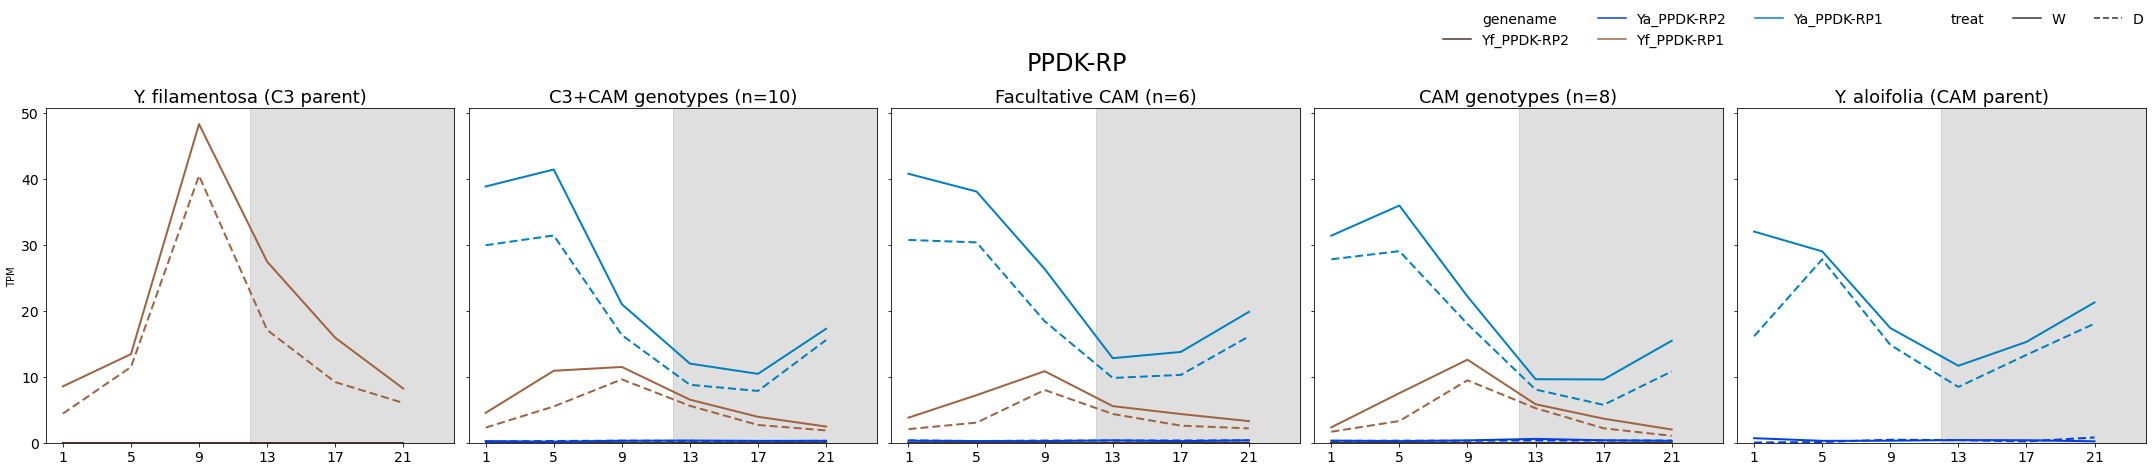

In [109]:
plot_genefam_withparents(ppdk_rp_dict)